# Customer Churn Prediction Using Machine Learning

## Project Overview

This project analyzes customer behavior and builds a machine learning model to predict whether a customer is likely to churn.

## GitHub Link 
- https://github.com/kamranakhter03/customer-churn-prediction-analysis

### Objectives
- Understand the customer churn dataset and its data quality.
- Explore customer behavior using Exploratory Data Analysis (EDA).
- Identify important patterns related to churn.
- Prepare numerical and categorical features correctly for machine learning.
- Train a Logistic Regression model.
- Evaluate the model using multiple classification metrics.
- Save the trained model and preprocessing objects for future use.
  
### Tools & Libraries
Python, Pandas, NumPy, Matplotlib, Seaborn, PostgreSQL, SQLAlchemy and Scikit-learn.

# 1. Import Required Libraries

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from lazypredict.Supervised import LazyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

# 2. Connect to PostgreSQL Database

In [2]:
host = "localhost"
user = "postgres"
port = 5432
password = os.getenv("POSTGRES_PASSWORD")
dbname = "customer_churn_db"

engine = create_engine(
    f"postgresql+psycopg://{user}:{password}@{host}:{port}/{dbname}"
)

print("Database connection configured successfully.")

Database connection configured successfully.


# 3. Load Data from PostgreSQL

In [3]:
query = "SELECT * FROM customer_churn"

df = pd.read_sql(query, engine)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 35,000
Columns: 36


# 4. Understand the Dataset

### 4.1 Preview the Data

In [4]:
df.head()

,customer_id,age,gender,region,city_tier,customer_segment,tenure_months,contract_type,subscription_plan,monthly_charges,total_charges,payment_method,auto_payment,paperless_billing,internet_service,phone_service,streaming_service,online_security,tech_support,device_protection,avg_monthly_usage_gb,num_logins_last_month,support_tickets_last_6_months,late_payments_last_year,customer_satisfaction,nps_score,discount_received,discount_percent,complaints_last_year,last_interaction_days,marketing_emails_opened,cross_sell_products,customer_lifetime_value,churn_risk_score,churn_reason,churn
0,CUST000001,59,Male,West,Tier 2,Basic,6,Month-to-Month,Plus,51.98,308.57,Bank Transfer,Yes,No,DSL,Yes,Yes,No,No,Yes,61.48,18,2,0,4.00,36,No,0.0,0,28,4,0,600.42,56.04,Not Churned,No
1,CUST000002,26,Male,South,Tier 1,Basic,28,Month-to-Month,Plus,46.27,1230.96,Credit Card,Yes,Yes,Fiber,Yes,Yes,Yes,No,Yes,3.63,22,1,0,3.46,39,Yes,30.0,1,34,5,0,1380.32,35.00,Not Churned,No
2,CUST000003,43,Female,Central,Tier 2,Premium,22,One Year,Starter,58.44,1331.25,Bank Transfer,Yes,Yes,Fiber,Yes,No,Yes,Yes,Yes,153.38,19,1,2,4.28,32,Yes,30.0,0,11,6,1,1658.17,0.00,Not Churned,No
3,CUST000004,46,Female,West,Tier 1,Premium,8,Month-to-Month,Plus,80.00,618.93,Debit Card,No,Yes,Fiber,Yes,No,Yes,No,No,169.90,18,4,2,2.39,20,No,0.0,3,20,3,2,817.77,98.16,Price,Yes
4,CUST000005,45,Other,North,Tier 2,Basic,22,Month-to-Month,Starter,20.51,435.21,Bank Transfer,No,Yes,None,Yes,No,Yes,Yes,No,0.00,15,0,1,4.50,33,No,0.0,1,5,3,0,375.55,35.15,Not Churned,No


### 4.2 Dataset Dimensions

In [5]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 35,000
Number of columns: 36


### 4.3 Column Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    35000 non-null  str    
 1   age                            35000 non-null  int64  
 2   gender                         35000 non-null  str    
 3   region                         35000 non-null  str    
 4   city_tier                      35000 non-null  str    
 5   customer_segment               35000 non-null  str    
 6   tenure_months                  35000 non-null  int64  
 7   contract_type                  35000 non-null  str    
 8   subscription_plan              35000 non-null  str    
 9   monthly_charges                35000 non-null  float64
 10  total_charges                  35000 non-null  float64
 11  payment_method                 35000 non-null  str    
 12  auto_payment                   35000 non-null  str    
 1

### 4.4 Descriptive Statistics — Numerical Columns

In [7]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,35000.0,41.23,12.53,18.00,32.00,41.00,50.00,80.00
tenure_months,35000.0,27.47,26.26,1.00,8.00,19.00,39.00,120.00
monthly_charges,35000.0,59.81,23.15,15.00,42.25,57.02,74.99,152.16
total_charges,35000.0,1651.72,1827.14,14.00,407.16,1035.74,2228.70,15406.80
avg_monthly_usage_gb,35000.0,110.73,64.42,0.00,63.75,110.75,155.50,365.57
num_logins_last_month,35000.0,20.48,6.04,3.00,16.00,20.00,24.00,48.00
support_tickets_last_6_months,35000.0,1.55,1.28,0.00,1.00,1.00,2.00,11.00
late_payments_last_year,35000.0,1.07,1.11,0.00,0.00,1.00,2.00,9.00
customer_satisfaction,35000.0,3.94,0.64,1.36,3.50,3.95,4.42,5.00
nps_score,35000.0,28.80,19.77,-48.00,15.00,29.00,43.00,100.00


### 4.5 Descriptive Statistics — Categorical Columns

In [8]:
df.describe(include=["object", "string"]).T

,count,unique,top,freq
customer_id,35000,35000,CUST000001,1
gender,35000,3,Female,17206
region,35000,5,West,7042
city_tier,35000,3,Tier 1,14838
customer_segment,35000,4,Standard,13181
contract_type,35000,3,Month-to-Month,19293
subscription_plan,35000,4,Plus,11956
payment_method,35000,5,Credit Card,11259
auto_payment,35000,2,No,19967
paperless_billing,35000,2,Yes,25201


### 4.6 Unique Values in Categorical Columns

In [9]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

for column in categorical_columns:
    if column != "customer_id":
        print(f"{column}: {df[column].unique().tolist()}")
        print(f"Cardinality: {df[column].nunique()}\n")

gender: ['Male', 'Female', 'Other']
Cardinality: 3

region: ['West', 'South', 'Central', 'North', 'East']
Cardinality: 5

city_tier: ['Tier 2', 'Tier 1', 'Tier 3']
Cardinality: 3

customer_segment: ['Basic', 'Premium', 'Standard', 'Enterprise']
Cardinality: 4

contract_type: ['Month-to-Month', 'One Year', 'Two Year']
Cardinality: 3

subscription_plan: ['Plus', 'Starter', 'Pro', 'Unlimited']
Cardinality: 4

payment_method: ['Bank Transfer', 'Credit Card', 'Debit Card', 'Digital Wallet', 'Cash']
Cardinality: 5

auto_payment: ['Yes', 'No']
Cardinality: 2

paperless_billing: ['No', 'Yes']
Cardinality: 2

internet_service: ['DSL', 'Fiber', 'None', 'Cable']
Cardinality: 4

phone_service: ['Yes', 'No']
Cardinality: 2

streaming_service: ['Yes', 'No']
Cardinality: 2

online_security: ['No', 'Yes']
Cardinality: 2

tech_support: ['No', 'Yes']
Cardinality: 2

device_protection: ['Yes', 'No']
Cardinality: 2

discount_received: ['No', 'Yes']
Cardinality: 2

churn_reason: ['Not Churned', 'Price', 'C

# 5. Data Quality Check

### 5.1 Missing Values

In [10]:
df.isnull().sum()

customer_id                      0
age                              0
gender                           0
region                           0
city_tier                        0
customer_segment                 0
tenure_months                    0
contract_type                    0
subscription_plan                0
monthly_charges                  0
total_charges                    0
payment_method                   0
auto_payment                     0
paperless_billing                0
internet_service                 0
phone_service                    0
streaming_service                0
online_security                  0
tech_support                     0
device_protection                0
avg_monthly_usage_gb             0
num_logins_last_month            0
support_tickets_last_6_months    0
late_payments_last_year          0
customer_satisfaction            0
nps_score                        0
discount_received                0
discount_percent                 0
complaints_last_year

- **Observation:** There are no missing values

### 5.2 Duplicate Rows

In [11]:
df.duplicated().sum()

np.int64(0)

- **Observation:** There are no duplicated rows

# 6. Exploratory Data Analysis (EDA)

## 6.1 Target Variable Analysis

In [12]:
churn_counts = df["churn"].value_counts()
churn_percentage = df["churn"].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_percentage
})

target_summary

,Count,Percentage
churn,,
No,25102,71.72
Yes,9898,28.28


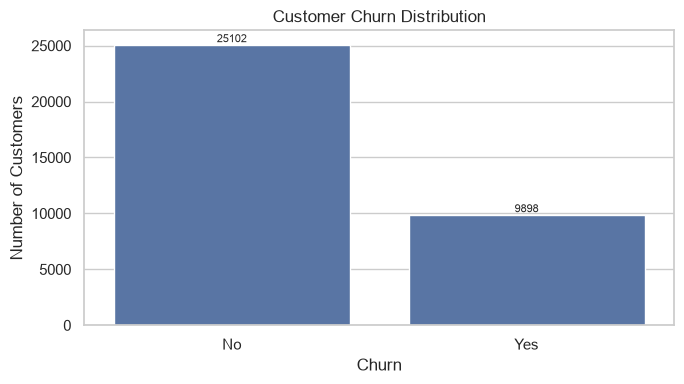

In [13]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x="churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.tight_layout()
plt.show()

**Target Variable Insights:**
- The dataset contains both churned and non-churned customers.
- Non-churned customers represent approximately 72% of the dataset.
- Churned customers represent approximately 28%.
- Therefore, the target variable shows class imbalance.

## 6.2 Univariate Analysis

#### 6.2.1 Numerical Feature Distributions

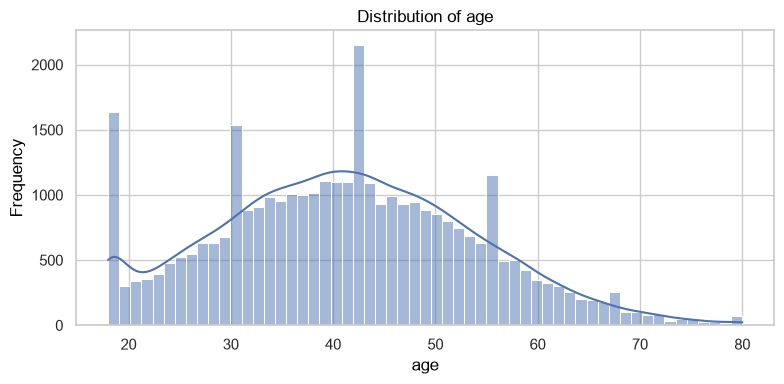

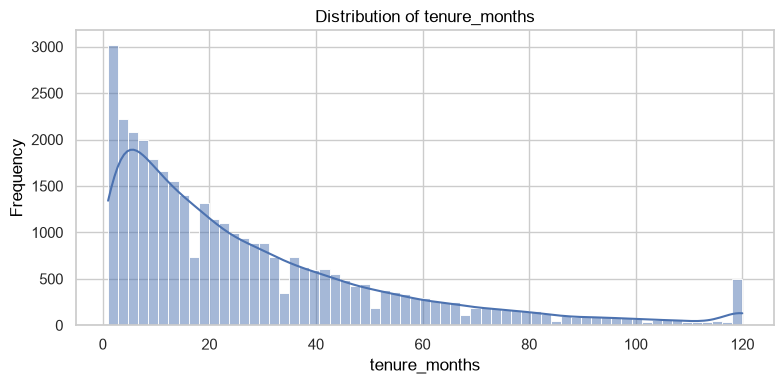

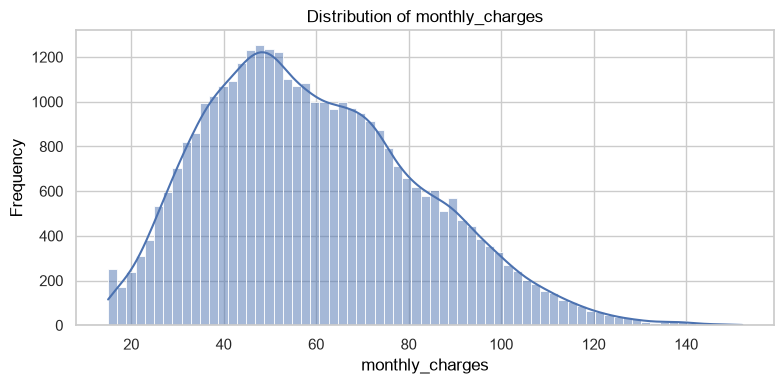

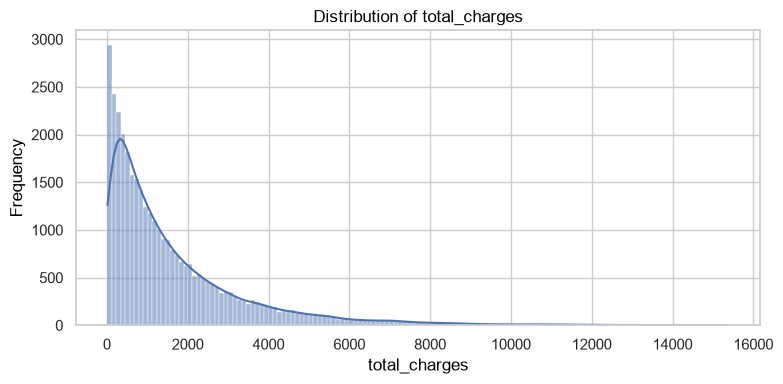

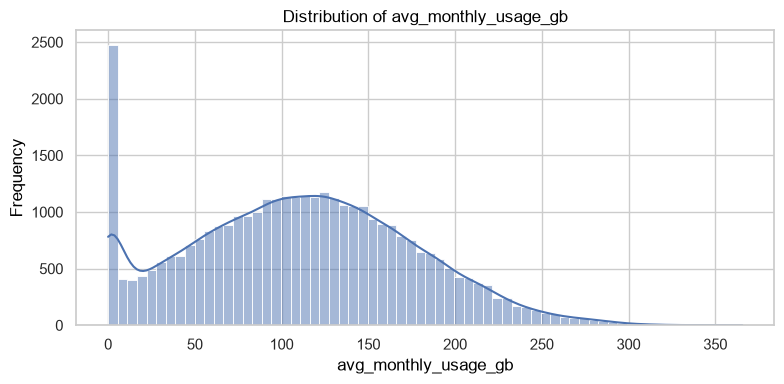

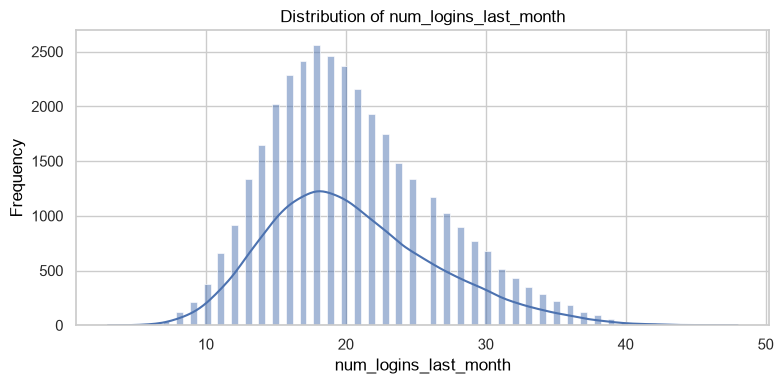

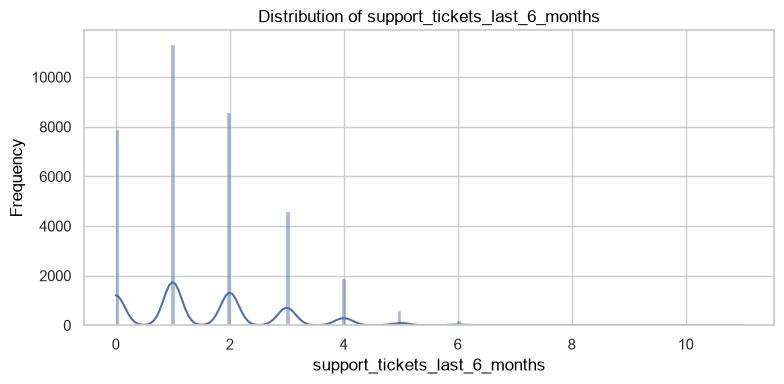

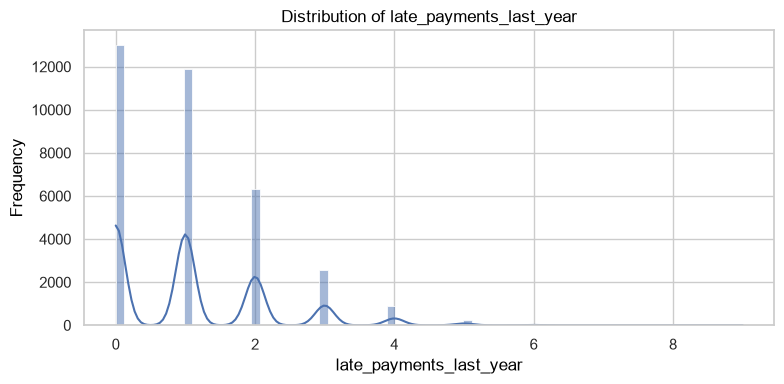

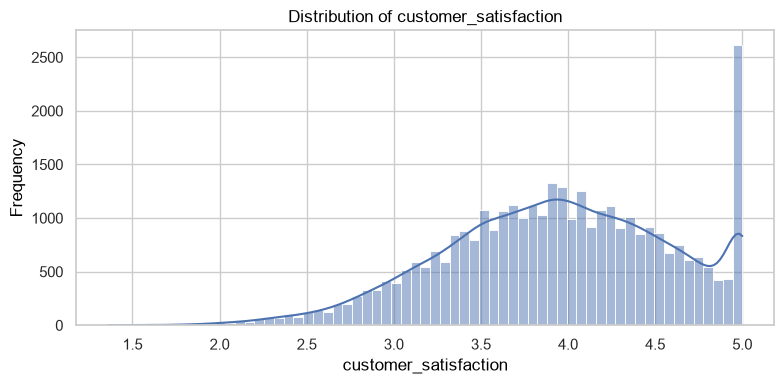

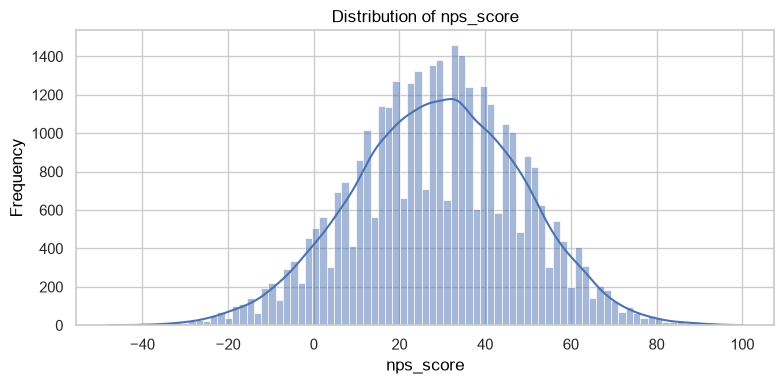

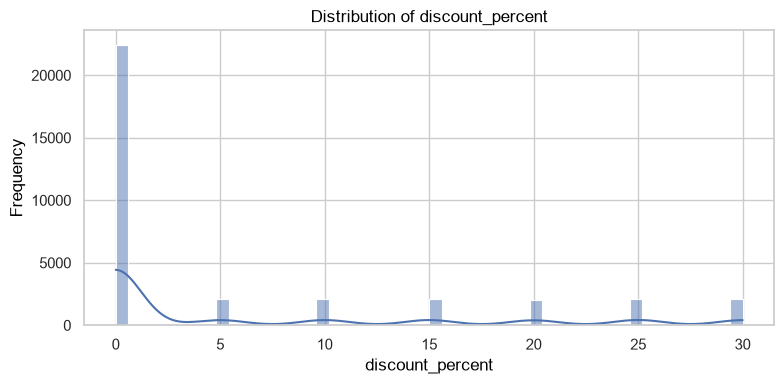

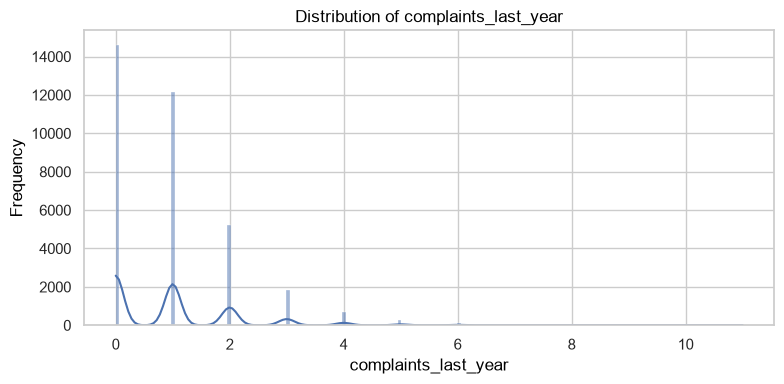

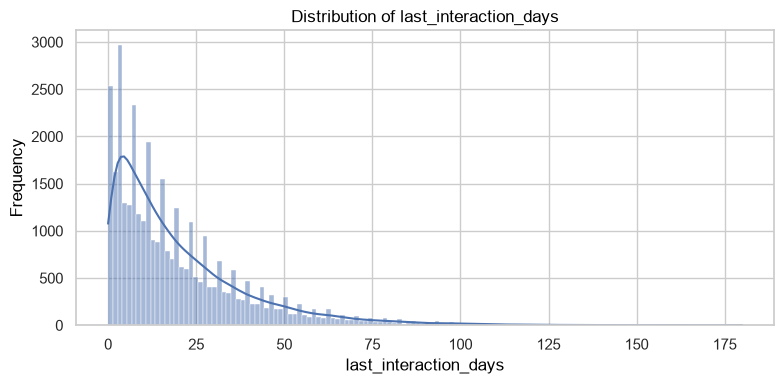

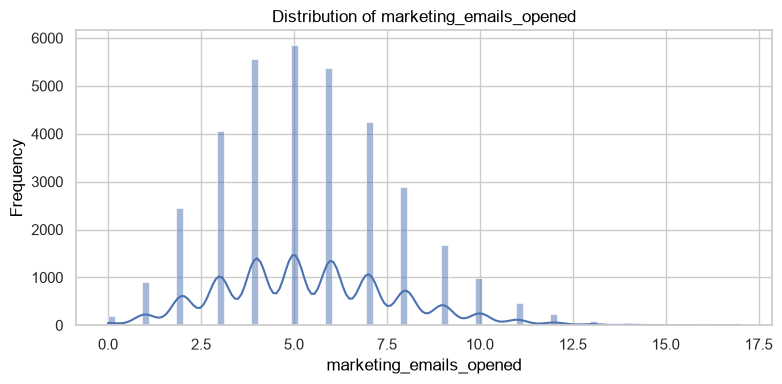

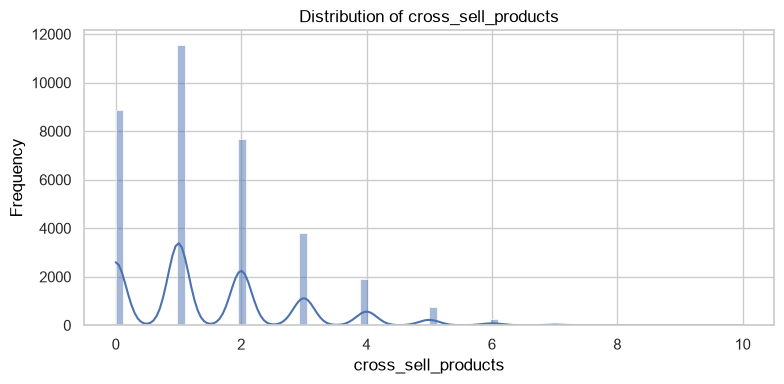

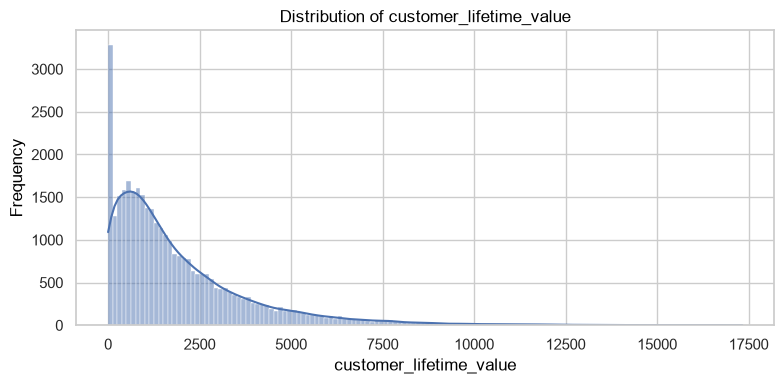

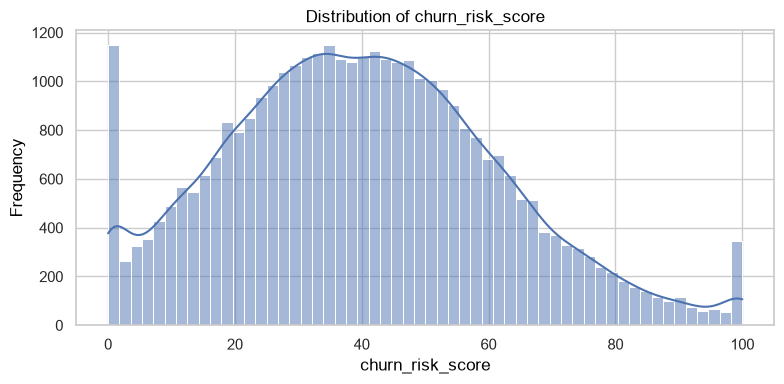

In [14]:
numerical_columns = df.select_dtypes(exclude=["str", "object"]).columns.tolist()

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Distribution of {column}", color='black')
    plt.xlabel(column, color='black')
    plt.ylabel("Frequency", color='black')
    plt.tight_layout()
    plt.show()

#### 6.2.2 Outlier Detection Using the IQR Method

In [15]:
numeric_df = df[numerical_columns]

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = (
    (numeric_df < lower_bound) | (numeric_df > upper_bound)
).sum()

outlier_percentage = (
    outlier_count / len(numeric_df) * 100
).round(2)

outlier_summary = pd.DataFrame({
    "Outlier_Count": outlier_count,
    "Outlier_Percentage": outlier_percentage
}).sort_values("Outlier_Percentage", ascending=False)

outlier_summary

,Outlier_Count,Outlier_Percentage
complaints_last_year,2993,8.55
support_tickets_last_6_months,2694,7.70
total_charges,2133,6.09
discount_percent,2082,5.95
customer_lifetime_value,1904,5.44
last_interaction_days,1639,4.68
tenure_months,1619,4.63
cross_sell_products,374,1.07
num_logins_last_month,376,1.07
marketing_emails_opened,374,1.07


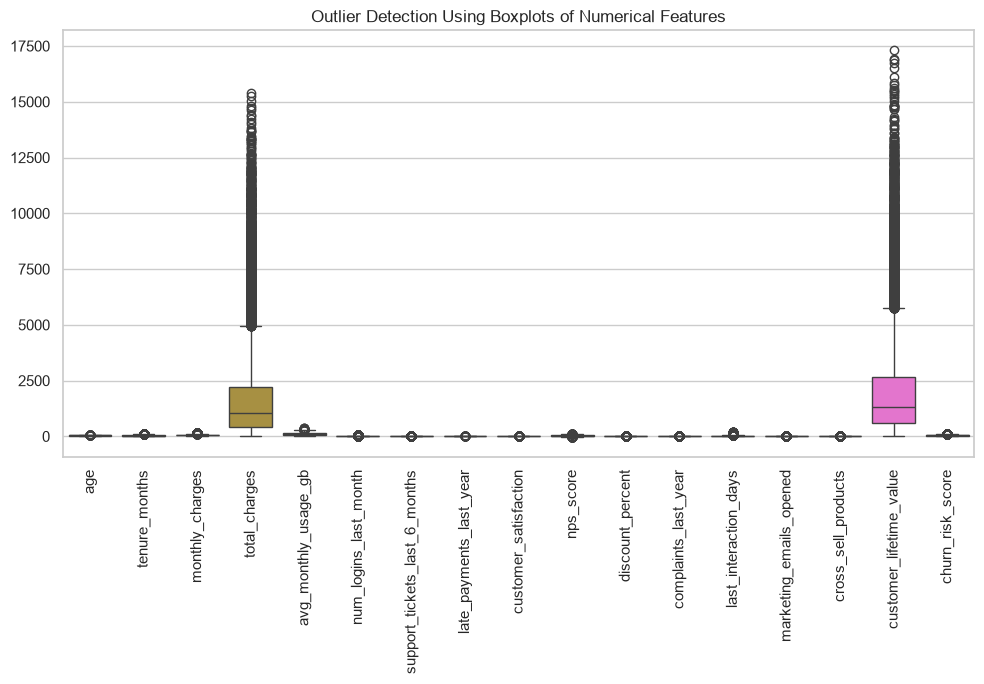

In [16]:
plt.figure(figsize=(10, 7))
sns.boxplot(data=numeric_df)
plt.title("Outlier Detection Using Boxplots of Numerical Features")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Observation: Outlier Analysis**

- Outliers are present in several numerical columns based on the IQR method.
- The highest outlier percentages are found in **complaints_last_year (8.55%)**, **support_tickets_last_6_months (7.70%)**, **total_charges (6.09%)**, **discount_percent (5.95%)**, and **customer_lifetime_value (5.44%)**.
- Other numerical columns contain relatively low percentages of outliers.
- Since several extreme values can represent genuine customer behavior rather than data-entry errors, the observations were retained instead of being removed solely based on the IQR rule.

#### 6.2.3 Categorical Feature Distributions

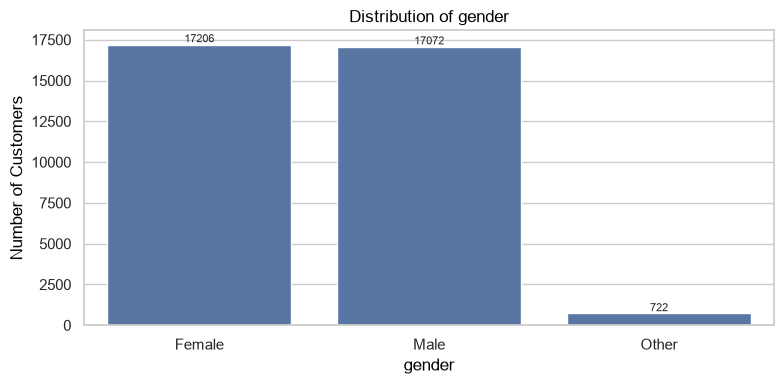

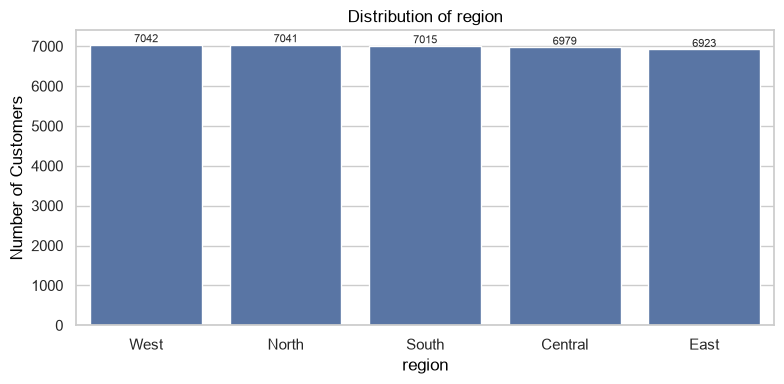

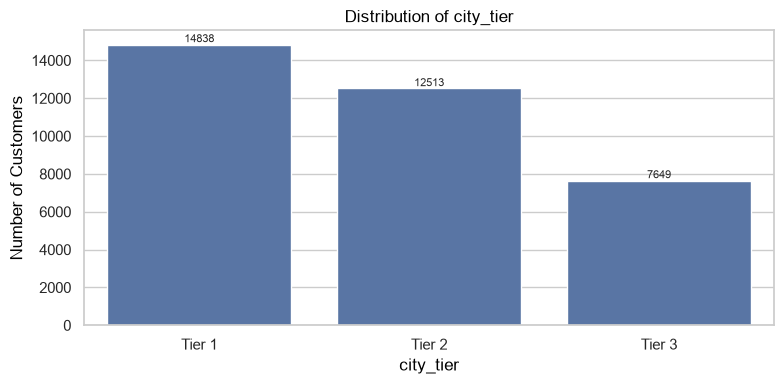

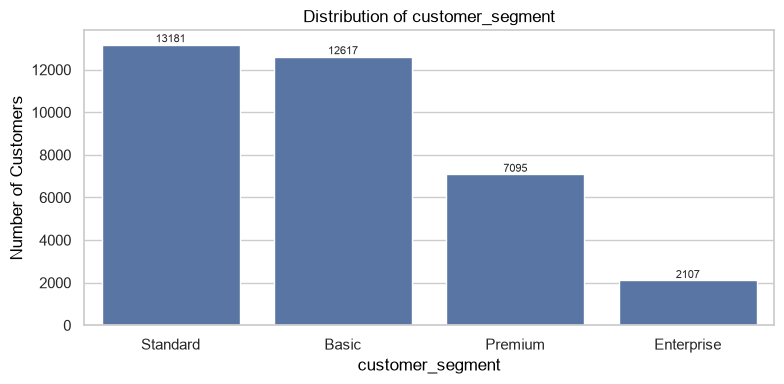

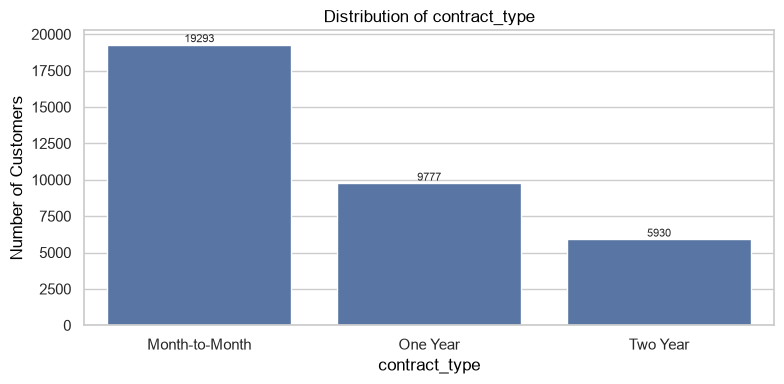

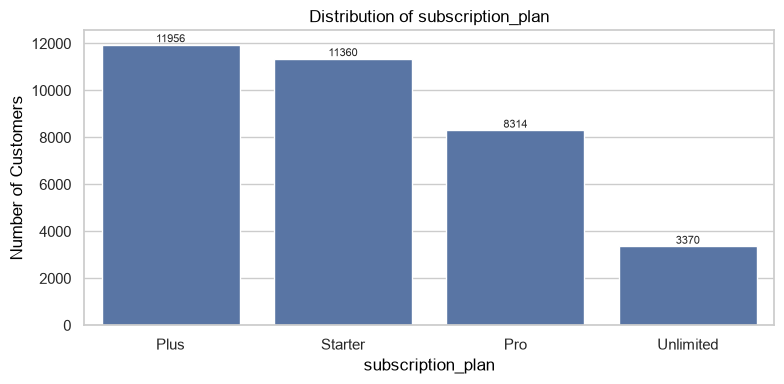

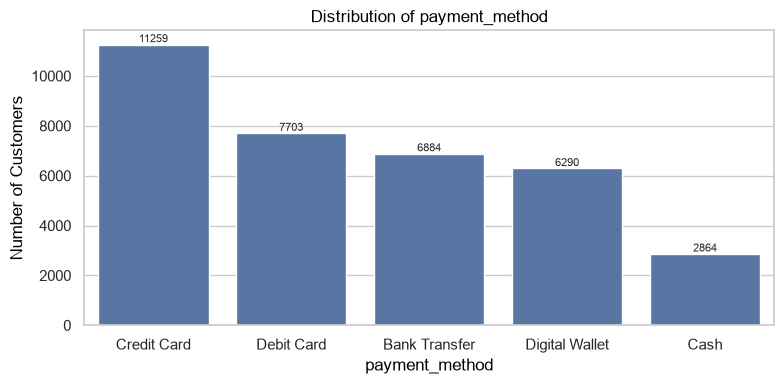

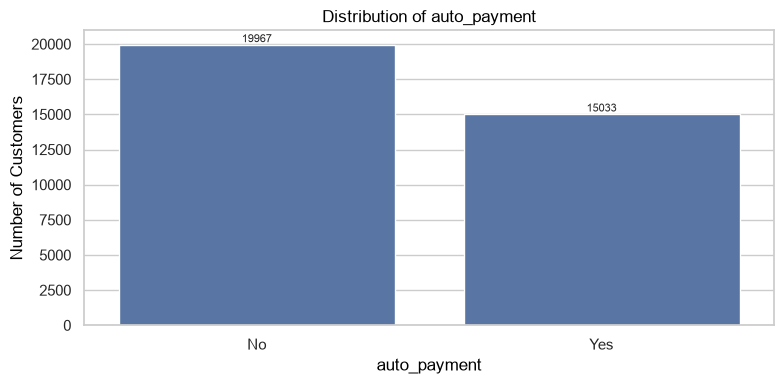

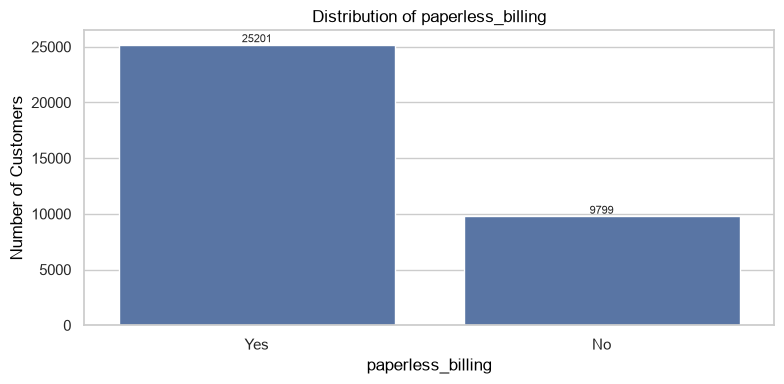

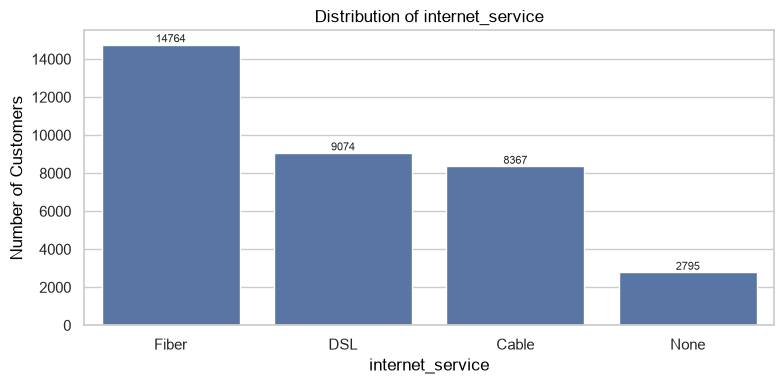

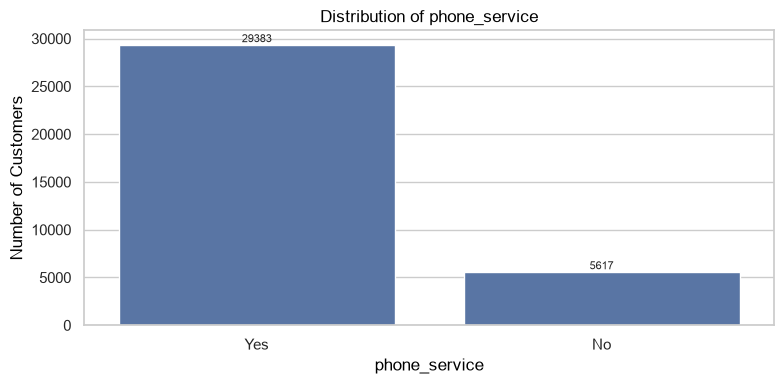

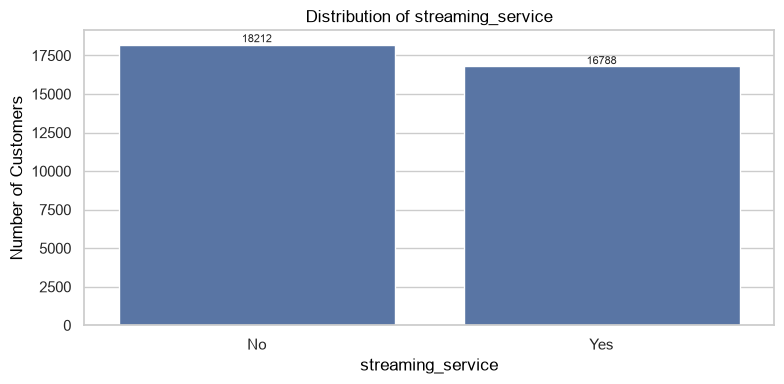

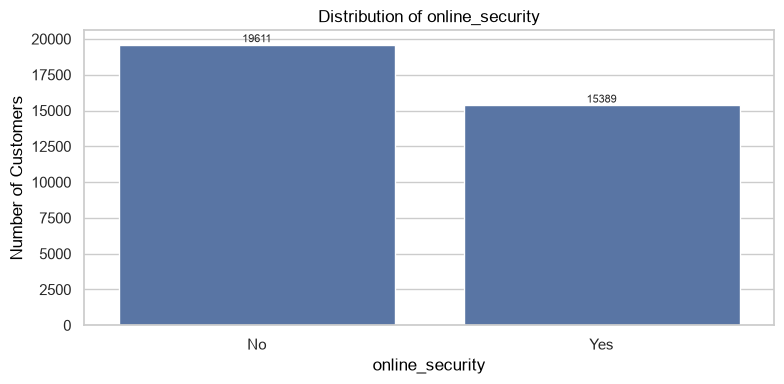

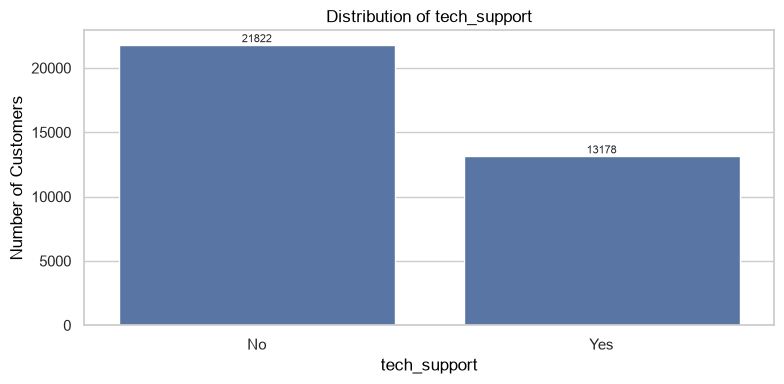

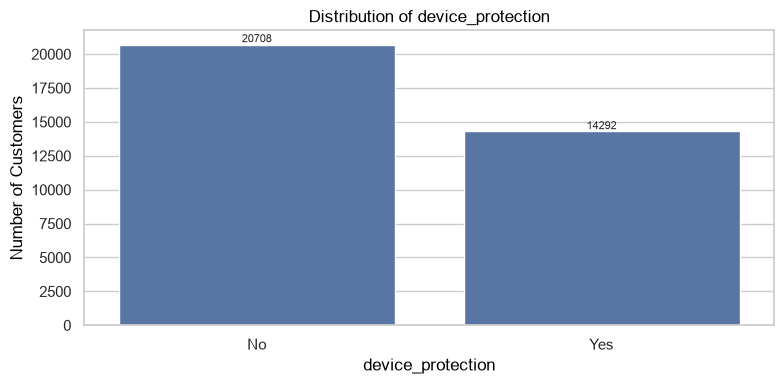

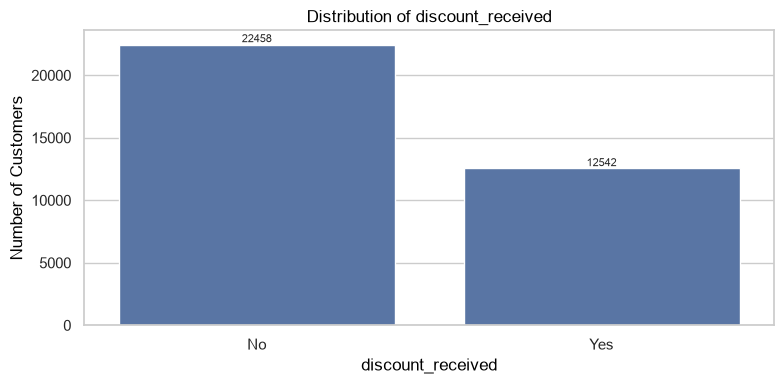

In [17]:
categorical_features = [
    col for col in df.select_dtypes(include=["object", "string"]).columns
    if col not in ["customer_id", "churn_reason", "churn"]
]

for column in categorical_features:
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(data=df, x=column, order=df[column].value_counts().index)
    plt.title(f"Distribution of {column}", color='black')
    plt.xlabel(column, color='black')
    plt.ylabel("Number of Customers", color='black')
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)
    plt.tight_layout()
    plt.show()

## 6.3 Bivariate Analysis

#### 6.3.1 Churn Rate by Categorical Features

In [18]:
for column in categorical_features:

    churn_rate = df.groupby(column)["churn"].apply(
        lambda x: (x == "Yes").mean() * 100
    ).round(2)

    print(f"Churn Rate by {column}")
    display(churn_rate.to_frame("Churn_Rate%").reset_index())

Churn Rate by gender


,gender,Churn_Rate%
0,Female,28.37
1,Male,28.18
2,Other,28.39


Churn Rate by region


,region,Churn_Rate%
0,Central,28.66
1,East,28.73
2,North,27.96
3,South,27.88
4,West,28.17


Churn Rate by city_tier


...

,tech_support,Churn_Rate%
0,No,36.37
1,Yes,14.89


Churn Rate by device_protection


,device_protection,Churn_Rate%
0,No,28.25
1,Yes,28.32


Churn Rate by discount_received


,discount_received,Churn_Rate%
0,No,30.35
1,Yes,24.57


**Observation: Categorical Features vs Churn**

- Contract type shows a strong relationship with churn. Month-to-Month customers have the highest churn rate (41.13%), compared with One Year (13.31%) and Two Year (11.16%) contracts.
- Customers without auto payment have a considerably higher churn rate (36.15%) than customers using auto payment (17.82%).
- Customers without tech support show a much higher churn rate (36.37%) compared with customers having tech support (14.89%).
- Customers without online security also show a higher churn rate (32.39%) than customers with online security (23.04%).
- Customers who did not receive a discount have a higher churn rate (30.35%) than customers who received a discount (24.57%).
- Cash and Debit Card users show relatively higher churn rates than the other payment methods.
- Gender, region, city tier, subscription plan, paperless billing, internet service, phone service, streaming service, and device protection show relatively small differences in churn rates.

#### 6.3.2 Numerical Features vs Churn

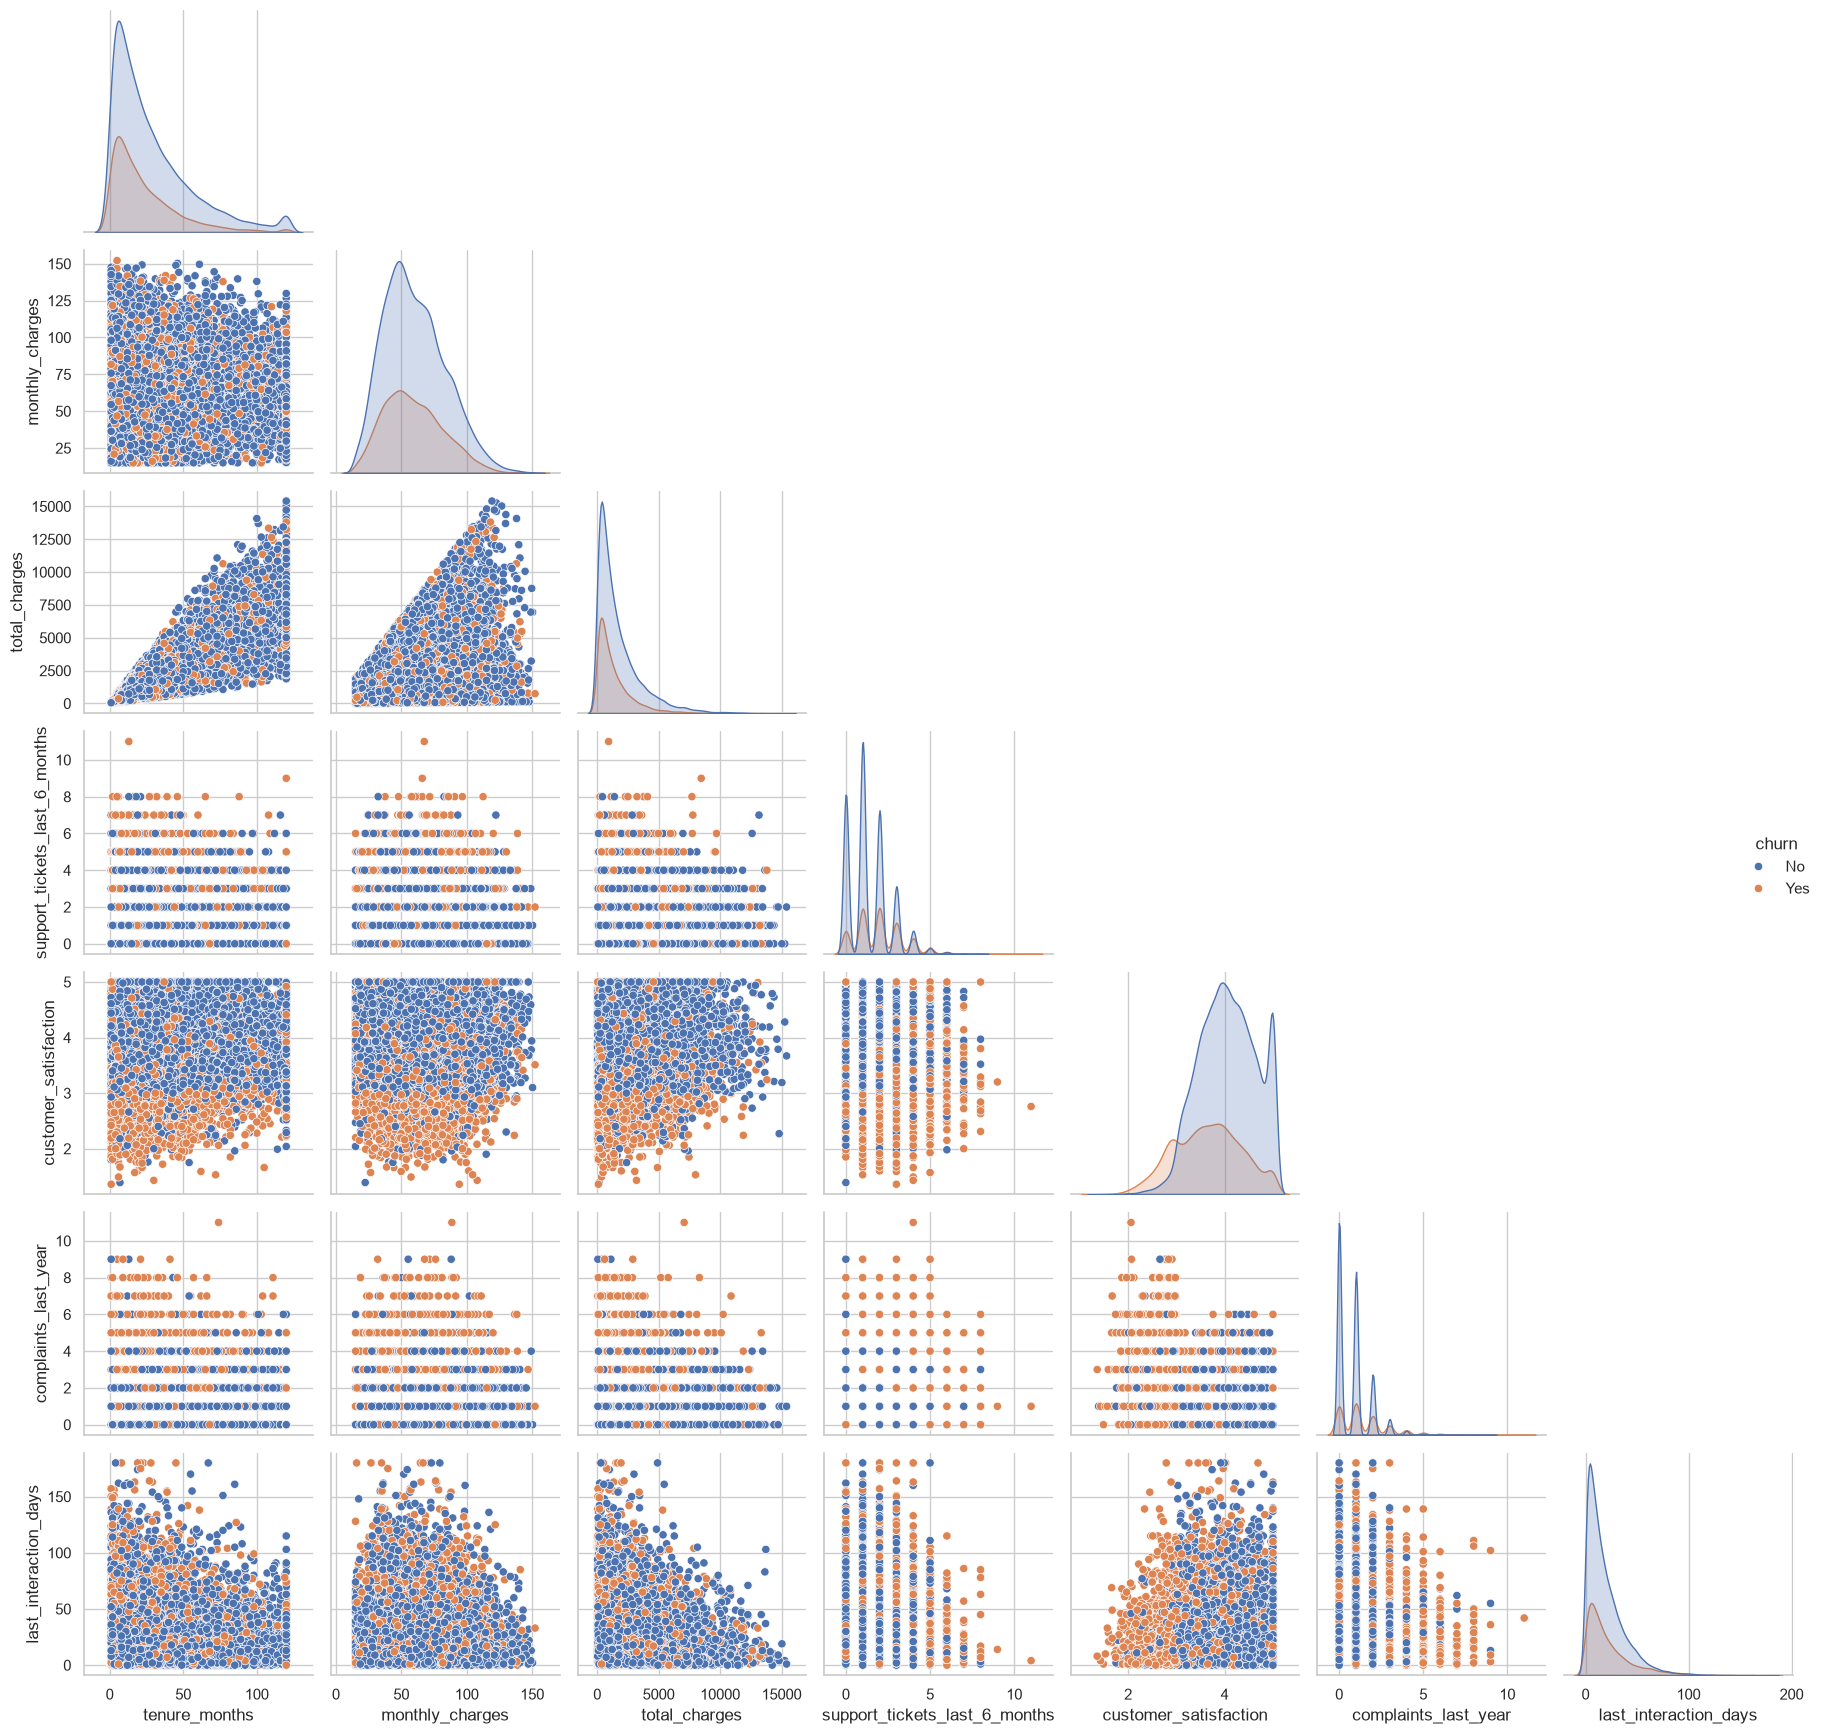

In [19]:
num = [
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "support_tickets_last_6_months",
    "customer_satisfaction",
    "complaints_last_year",
    "last_interaction_days"
]

sns.pairplot(
    df,
    vars = df[num].columns,
    hue='churn',
    corner=True
)
plt.tight_layout()
plt.show()

**Observation: Numerical Features vs Churn**

- The pairplot was used to visually compare the distributions and relationships of selected numerical features for churned and non-churned customers.
- Some overlap is visible between the two churn classes, indicating that customer churn is unlikely to be explained by a single numerical feature alone.
- Therefore, multiple customer behavior, billing, service, and engagement features are considered together during model development.

## 6.4. Correlation and Multicollinearity Analysis

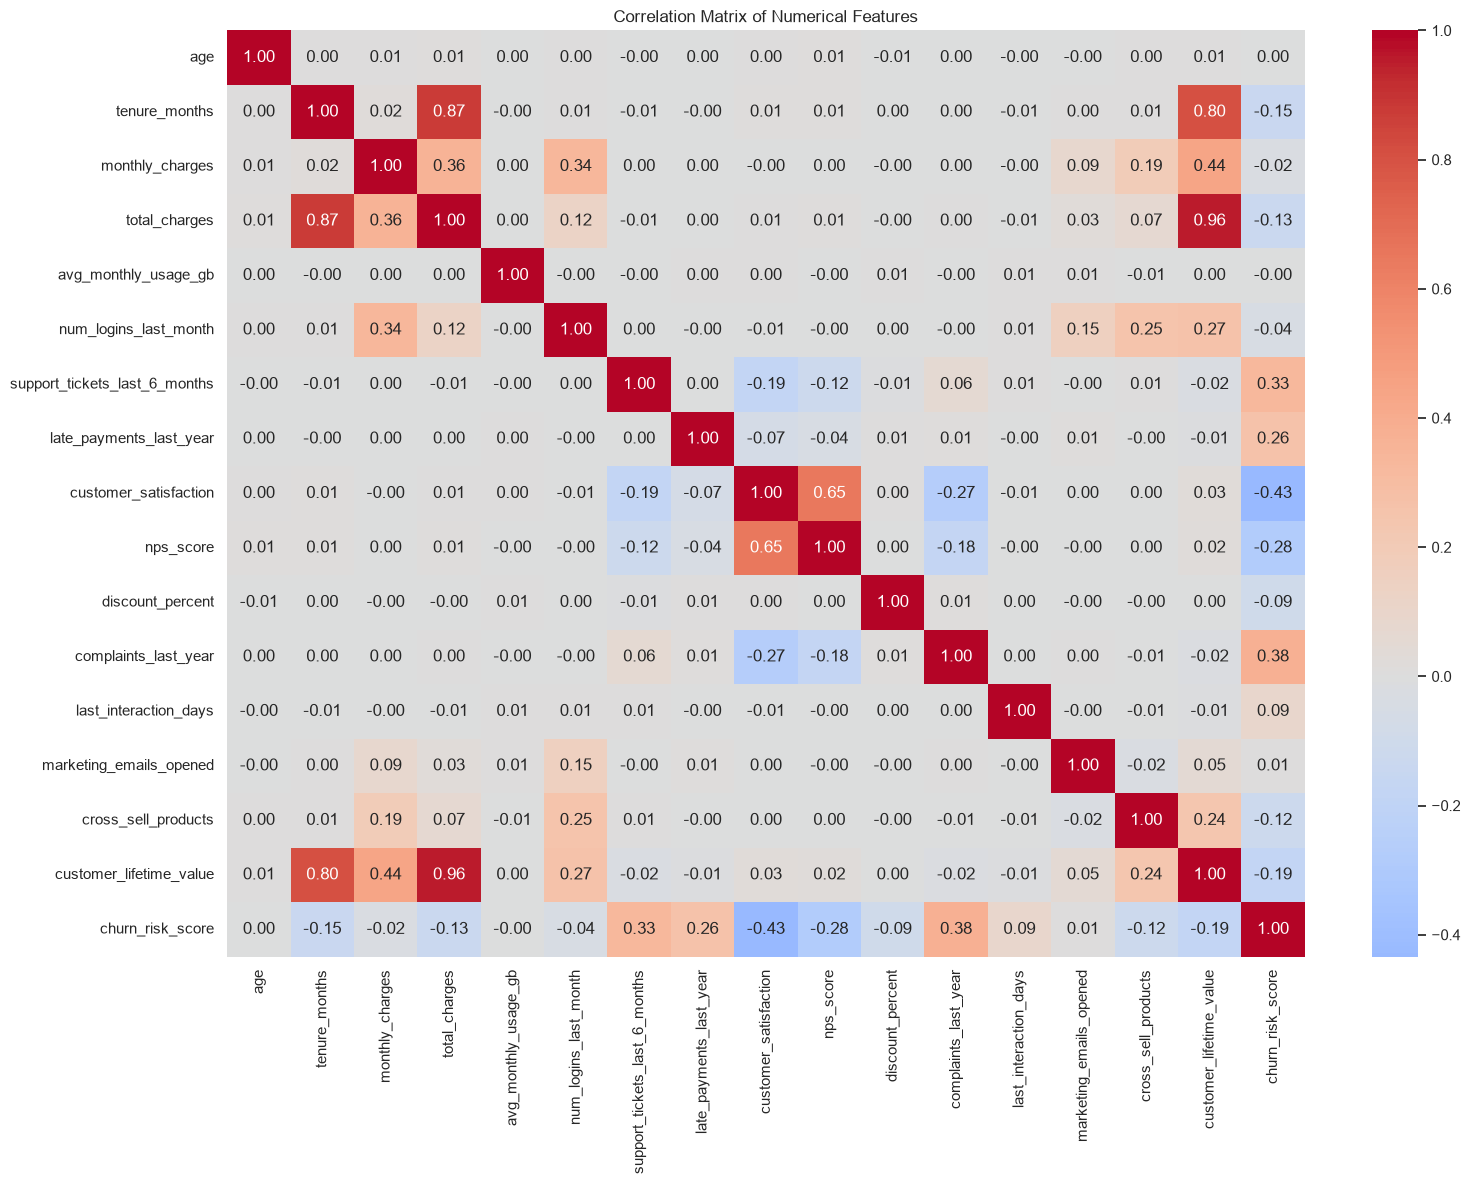

In [20]:
corr_mat = df[numerical_columns].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

##### **Observation: Correlation Analysis**

- `customer_lifetime_value` and `total_charges` are **highly correlated (0.96)**, indicating strong redundancy between the two features.
- `customer_lifetime_value` and `tenure_months` are **highly correlated (0.80)**, suggesting that customer lifetime value is strongly related to the customer's tenure.
- `total_charges` and `tenure_months` are **highly correlated (0.87)**, indicating that total charges are strongly influenced by the length of the customer's subscription.
- `nps_score` and `customer_satisfaction` are **correlated (0.65)**, suggesting that both features capture similar aspects of customer satisfaction.

**Conclusion:** Strongly correlated features were reviewed for potential redundancy. Based on the correlation analysis and feature relevance, selected redundant features were removed before model training to reduce multicollinearity.

# 7. Data Preprocessing

### 7.1 Unnecessary Columns Removed

In [21]:
df.drop(columns=[
    'customer_id',
    'customer_lifetime_value',
    'total_charges',
    'nps_score',
    'churn_risk_score',
    'churn_reason',
    'gender',
    'region',
    'city_tier',
    'subscription_plan',
    'paperless_billing',
    'internet_service',
    'phone_service',
    'streaming_service',
    'device_protection'], inplace=True)

Above features were removed based on their relevance to the modeling task:

- customer_id — Identifier column; does not provide predictive information.
- customer_lifetime_value — Highly correlated with other total_charges and tenure-months, creating redundancy.
- total_charges — Highly correlated with tenure-months, creating redundancy.
- nps_score — Correlated with customer_satisfaction, so one of the two was removed to reduce redundancy.
- churn_risk_score — Potentially derived from churn-related information and may introduce data leakage.
- churn_reason — Directly related to the churn outcome and can cause data leakage.
- gender, region, city_tier, subscription_plan, paperless_billing, internet_service, phone_service, streaming_service, device_protection — Showed relatively weak relationships with churn based on the categorical churn-rate analysis.

Reason: Removing redundant, identifier, leakage-prone, and relatively low-impact features helps create a cleaner and more relevant feature set for model development.

In [22]:
df.head(1)

,age,customer_segment,tenure_months,contract_type,monthly_charges,payment_method,auto_payment,online_security,tech_support,avg_monthly_usage_gb,num_logins_last_month,support_tickets_last_6_months,late_payments_last_year,customer_satisfaction,discount_received,discount_percent,complaints_last_year,last_interaction_days,marketing_emails_opened,cross_sell_products,churn
0,59,Basic,6,Month-to-Month,51.98,Bank Transfer,Yes,No,No,61.48,18,2,0,4.0,No,0.0,0,28,4,0,No


### 7.2 Encode Target Column

In [23]:
target_encoder = LabelEncoder()
df['churn'] = target_encoder.fit_transform(df['churn'])

In [24]:
df.head(2)

,age,customer_segment,tenure_months,contract_type,monthly_charges,payment_method,auto_payment,online_security,tech_support,avg_monthly_usage_gb,num_logins_last_month,support_tickets_last_6_months,late_payments_last_year,customer_satisfaction,discount_received,discount_percent,complaints_last_year,last_interaction_days,marketing_emails_opened,cross_sell_products,churn
0,59,Basic,6,Month-to-Month,51.98,Bank Transfer,Yes,No,No,61.48,18,2,0,4.00,No,0.0,0,28,4,0,0
1,26,Basic,28,Month-to-Month,46.27,Credit Card,Yes,Yes,No,3.63,22,1,0,3.46,Yes,30.0,1,34,5,0,0


### 7.3 Separated Features (X) and Target Columns (Y)

In [25]:
X = df.drop('churn', axis=1)
y = df['churn']

### 7.4 Splitting Data into Training and Testing Sets

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (28000, 20)
Testing set: (7000, 20)


### 7.5 Encode Categorical Features

In [27]:
encoders = {}

categorical_columns = X_train.select_dtypes(
    include=['object', 'string']
).columns.tolist()

for column in categorical_columns:
    if X_train[column].nunique() > 2:
        OHE = OneHotEncoder(
            drop='first',
            dtype=int,
            sparse_output=False,
            handle_unknown='ignore'
        )
        # Fit only on training data
        train_encoded = OHE.fit_transform(X_train[[column]])
        # Use same fitted encoder on testing data
        test_encoded = OHE.transform(X_test[[column]])
        train_encoded_df = pd.DataFrame(
            train_encoded,
            columns=OHE.get_feature_names_out([column]),
            index=X_train.index
        )

        test_encoded_df = pd.DataFrame(
            test_encoded,
            columns=OHE.get_feature_names_out([column]),
            index=X_test.index
        )

        X_train = pd.concat(
            [X_train.drop(columns=[column]), train_encoded_df],
            axis=1
        )

        X_test = pd.concat(
            [X_test.drop(columns=[column]), test_encoded_df],
            axis=1
        )
        encoders[column] = OHE

    else:
        LE = LabelEncoder()
        # Fit only on training data
        X_train[column] = LE.fit_transform(X_train[column])
        # Use same fitted encoder on testing data
        X_test[column] = LE.transform(X_test[column])
        encoders[column] = LE

In [28]:
for column, encoder in encoders.items():
    print(column, ":", encoder)

customer_segment : OneHotEncoder(drop='first', dtype=<class 'int'>, handle_unknown='ignore',
              sparse_output=False)
contract_type : OneHotEncoder(drop='first', dtype=<class 'int'>, handle_unknown='ignore',
              sparse_output=False)
payment_method : OneHotEncoder(drop='first', dtype=<class 'int'>, handle_unknown='ignore',
              sparse_output=False)
auto_payment : LabelEncoder()
online_security : LabelEncoder()
tech_support : LabelEncoder()
discount_received : LabelEncoder()


In [29]:
feature_columns = X_train.columns.tolist()

print("Total model features:", len(feature_columns))
print(feature_columns)

Total model features: 26
['age', 'tenure_months', 'monthly_charges', 'auto_payment', 'online_security', 'tech_support', 'avg_monthly_usage_gb', 'num_logins_last_month', 'support_tickets_last_6_months', 'late_payments_last_year', 'customer_satisfaction', 'discount_received', 'discount_percent', 'complaints_last_year', 'last_interaction_days', 'marketing_emails_opened', 'cross_sell_products', 'customer_segment_Enterprise', 'customer_segment_Premium', 'customer_segment_Standard', 'contract_type_One Year', 'contract_type_Two Year', 'payment_method_Cash', 'payment_method_Credit Card', 'payment_method_Debit Card', 'payment_method_Digital Wallet']


### 7.6 Standardize the Features

In [30]:
Scaler = StandardScaler()
X_train = Scaler.fit_transform(X_train)
X_test = Scaler.transform(X_test)

# 8. Building Model

In [31]:
import lazypredict
print(lazypredict.__version__)

0.3.0


In [32]:
selected_models = [
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    XGBClassifier,
    SVC,
    KNeighborsClassifier,
    GaussianNB
]

clf = LazyClassifier(
    classifiers=selected_models,
    verbose=1,
    ignore_warnings=True
)

models, predictions = clf.fit(
    X_train,
    X_test,
    y_train,
    y_test
)

  0%|          | 0/9 [00:00<?, ?it/s]

In [33]:
print(models)

                            Accuracy  Balanced Accuracy   ROC AUC  F1 Score  \
Model                                                                         
AdaBoostClassifier          0.821714           0.747547  0.872534  0.814557   
LogisticRegression          0.815429           0.745611  0.872001  0.809551   
XGBClassifier               0.811429           0.745269  0.859491  0.806587   
GradientBoostingClassifier  0.819571           0.739936  0.874811  0.810966   
GaussianNB                  0.792857           0.738591  0.838248  0.791540   
SVC                         0.812857           0.731738  0.861653  0.803953   
RandomForestClassifier      0.812571           0.731538  0.860357  0.803699   
KNeighborsClassifier        0.779000           0.694828  0.785933  0.770103   
DecisionTreeClassifier      0.731714           0.681434  0.681434  0.734716   

                            Precision    Recall  Time Taken  
Model                                                        
AdaBoo

### Model Selection
- Although AdaBoost achieved slightly higher accuracy, Logistic Regression was selected as the final model because it provided comparable performance while being simpler and easier to interpret.

In [34]:
# Initializing the Logistic Regression 
LR_model = LogisticRegression()

# Train the Model
LR_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

# 9. Make Predictions

In [35]:
y_pred = LR_model.predict(X_test)

# 10. Model Evaluation

In [36]:
score = LR_model.score(X_test, y_test)
print(score)

0.8154285714285714


### Classification Report

In [37]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.91      0.88      5020
       Churn       0.71      0.58      0.64      1980

    accuracy                           0.82      7000
   macro avg       0.78      0.75      0.76      7000
weighted avg       0.81      0.82      0.81      7000



#### **Model Evaluation Insights**

- The Logistic Regression model achieved approximately 81.54% accuracy on the test data.
- For churned customers, the model achieved 71% precision, 58% recall, and an F1-score of 64%.
- The model performs better at identifying non-churned customers, with 91% recall for the No Churn class.
- The 58% churn recall indicates that the model still misses some customers who actually churn.
- Therefore, the model provides a useful baseline for churn prediction, while churn detection could be further improved through model tuning or techniques for handling class imbalance.

# 11. Save Model and Preprocessing Objects

In [38]:
from pathlib import Path

MODEL_DIR = Path("../model")
MODEL_DIR.mkdir(exist_ok=True)

In [39]:
joblib.dump(LR_model, MODEL_DIR / "prediction_model.pkl")
joblib.dump(encoders, MODEL_DIR / "encoders.pkl")
joblib.dump(Scaler, MODEL_DIR / "scaler.pkl")
joblib.dump(feature_columns, MODEL_DIR / "feature_columns.pkl")

print("Model and preprocessing objects saved successfully.")

Model and preprocessing objects saved successfully.


## Results and Conclusion

This project analyzed customer churn patterns and developed a Logistic Regression model to predict whether a customer is likely to churn.

### Key Findings

- The dataset contains 35,000 customer records with no missing or duplicate rows.
- Approximately 28.28% of customers churned, indicating an imbalanced target distribution.
- Month-to-Month customers showed the highest churn rate (41.13%), while customers with longer contracts had considerably lower churn rates.
- Customers without auto payment and without tech support showed substantially higher churn rates.
- Customers without online security and customers who did not receive discounts also showed higher churn rates.
- Several numerical features were strongly correlated, so redundant and leakage-prone features were removed before model training.

### Model Performance

The final Logistic Regression model achieved approximately 81.54% accuracy on the test set. For churned customers, the model achieved 71% precision, 58% recall, and a 64% F1-score.

The model provides a useful baseline for identifying customers at risk of churn, although churn recall could be improved further through model tuning or techniques for handling class imbalance.

Finally, the trained model, categorical encoders, scaler, and feature-column order were saved so that the same preprocessing pipeline can be reused by the Flask prediction application.